In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
df_city_bikes = pd.read_csv("df_city_bikes.csv")
df_yelp = pd.read_csv("yelp_data.csv")

In [13]:
print("City Bikes Columns:", df_city_bikes.columns)
print("Yelp Data Columns:", df_yelp.columns)

City Bikes Columns: Index(['unnamed: 0', 'station id', 'station name', 'latitude', 'longitude',
       'free bikes', 'availability'],
      dtype='object')
Yelp Data Columns: Index(['unnamed: 0', 'name', 'distance', 'rating', 'station name'], dtype='object')


In [15]:
df_city_bikes.columns = df_city_bikes.columns.str.strip().str.lower()
df_yelp.columns = df_yelp.columns.str.strip().str.lower()

In [17]:
df_city_bikes.rename(columns={"name": "station name"}, inplace=True)

In [19]:
df = pd.merge(df_yelp, df_city_bikes, on="station name", how="inner")

In [21]:
print("Merged DataFrame Columns:", df.columns)
print("First few rows of merged data:")
print(df.head())

Merged DataFrame Columns: Index(['unnamed: 0_x', 'name', 'distance', 'rating', 'station name',
       'unnamed: 0_y', 'station id', 'latitude', 'longitude', 'free bikes',
       'availability'],
      dtype='object')
First few rows of merged data:
   unnamed: 0_x                 name     distance  rating station name  \
0             0       De Binnenkomer   599.407294     4.7      Alkmaar   
1             1  Vers Eten & Drinken    77.343360     4.5      Alkmaar   
2             2             Daikichi    54.041312     4.0      Alkmaar   
3             3          Burger King    38.753210     3.0      Alkmaar   
4             4                 Deli  1009.748379     4.8      Alkmaar   

   unnamed: 0_y                        station id  latitude  longitude  \
0             0  009ac5a5dfe1e13da61ea613ebd580dd  52.63753    4.73985   
1             0  009ac5a5dfe1e13da61ea613ebd580dd  52.63753    4.73985   
2             0  009ac5a5dfe1e13da61ea613ebd580dd  52.63753    4.73985   
3          

In [23]:
required_columns = ["distance", "rating", "free bikes"]
missing_columns = [col for col in required_columns if col not in df.columns]

In [25]:
if missing_columns:
    print(f"Warning: The following columns are missing: {missing_columns}")
    for col in missing_columns:
        df[col] = np.nan

In [27]:
df_cleaned = df.dropna(subset=required_columns)

In [29]:
conn = sqlite3.connect("bike_data.db")
df_cleaned.to_sql("bike_stations", conn, if_exists="replace", index=False)
conn.close()
print("Data successfully saved to bike_data.db")

Data successfully saved to bike_data.db


In [31]:
print("Missing Values After Cleaning:")
print(df_cleaned.isnull().sum())

Missing Values After Cleaning:
unnamed: 0_x    0
name            0
distance        0
rating          0
station name    0
unnamed: 0_y    0
station id      0
latitude        0
longitude       0
free bikes      0
availability    0
dtype: int64


In [33]:
df_cleaned = df_cleaned.drop_duplicates()

In [35]:
print("Summary Statistics:")
print(df_cleaned.describe())

Summary Statistics:
       unnamed: 0_x     distance       rating  unnamed: 0_y     latitude  \
count   7500.000000  7500.000000  7500.000000   7500.000000  7500.000000   
mean    3749.500000   756.651009     3.802000     76.093333    52.118393   
std     2165.207842   327.394194     1.465224     46.829375     0.461831   
min        0.000000    38.753210     0.000000      0.000000    50.849620   
25%     1874.750000   525.210743     3.300000     37.000000    51.889730   
50%     3749.500000   831.907047     4.050000     74.500000    52.090014   
75%     5624.250000  1009.748379     5.000000    112.000000    52.375859   
max     7499.000000  1485.845354     5.000000    240.000000    53.333643   

         longitude   free bikes  availability  
count  7500.000000  7500.000000   7500.000000  
mean      5.326834    50.646667      0.953333  
std       0.689121   103.362080      0.210938  
min       3.617680     0.000000      0.000000  
25%       4.873381     6.000000      1.000000  
50%    

Text(0.5, 1.0, 'Distribution of Ratings')

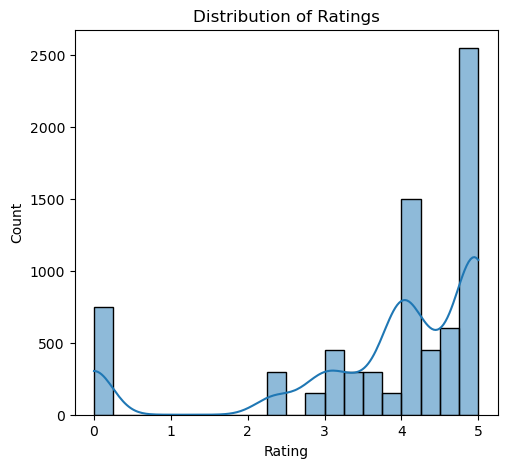

In [37]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_cleaned["rating"], bins=20, kde=True)
plt.xlabel("Rating")
plt.title("Distribution of Ratings")

In [ ]:
plt.subplot(1,2,2)
sns.histplot(df_cleaned["distance"], bins=20, kde=True)
plt.xlabel("Distance")
plt.title("Distribution of Distances")
plt.show()

# --- Correlation Analysis ---
plt.figure(figsize=(8,6))
numeric_df = df_cleaned.select_dtypes(include=[np.number]).drop(columns=["unnamed: 0_x", "unnamed: 0_y"], errors="ignore")
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# --- Bike Availability by Location (Limited to Top 20 for Readability) ---
plt.figure(figsize=(12,6))
top_stations = df_cleaned["station name"].value_counts().index[:20]  # Show only top 20 stations
filtered_df = df_cleaned[df_cleaned["station name"].isin(top_stations)]
sns.boxplot(x="station name", y="free bikes", data=filtered_df)
plt.xticks(rotation=45, ha="right")  # Rotate for readability
plt.title("Bike Availability by Station (Top 20)")
plt.show()

# --- Grouped Analysis (Bike Availability) ---
avg_bike_availability = df_cleaned.groupby("station name")["free bikes"].mean().sort_values(ascending=False)
print("Top 10 Stations with Most Available Bikes:")
print(avg_bike_availability.head(10))